In [43]:
import os 

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader

from tqdm import tqdm
import matplotlib.pyplot as plt

from DCGAN.vectorized_unet import VectorizedUNet
from DCGAN.unet import UNet

from CityScapes.datasets import CityScapesMultiResolutionDataset
from DCGAN.loss_functions import GradientPenaltyLoss, EntropyLoss, DriftLoss, WeightedMSELoss, TotalVariationLoss

device ="cuda" if torch.cuda.is_available() else "cpu"
scale_for_display = lambda x: x.mul(0.5).add(0.5)

In [44]:
channels = [512,256,128,64,32,32,16]
vectorizer_output_channels = [i for i in channels[:-1]]
degrees_of_freedom = [64 for i in channels]
n_components= 4

seg_gen_cut_connections = 2

batch_size = 16
rec_model_lr = 1.0e-4
seg_model_lr = 1.0e-5

In [45]:

msg_dataset = CityScapesMultiResolutionDataset()
train_loader = DataLoader(msg_dataset, batch_size=batch_size, shuffle=True)

rec_model = VectorizedUNet(channels=channels,
                           number_of_components=n_components,
                           vectorizer_output_channels=vectorizer_output_channels).to(device)
seg_model = UNet(channels=channels,
                 out_channels=n_components,
                 cut_connections=seg_gen_cut_connections).to(device)

rec_model_optimizer = optim.Adam(rec_model.parameters(), lr=rec_model_lr)
seg_model_optimizer = optim.Adam(seg_model.parameters(), lr=seg_model_lr)

Dataset initialized with 19998 samples. Labels enabled: False


/tmp/ipykernel_326932/1887186688.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


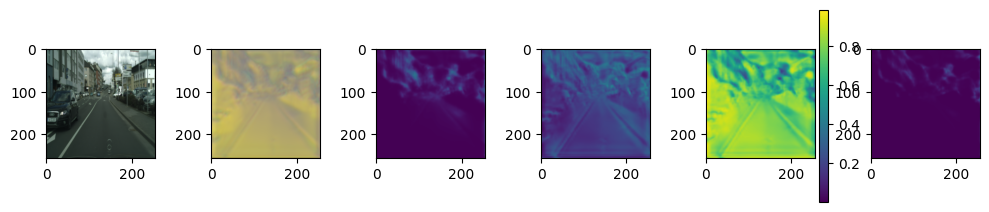

In [46]:
data,_ = next(iter(train_loader)) 

with torch.no_grad():
    x = data[-1].to(device)
    seg = seg_model(x)
    y= rec_model(x,seg)

components = seg.shape[1]

fig,ax = plt.subplots(1,2+components,figsize=(10,5))
scaled_x = scale_for_display(x)
sclaed_y = scale_for_display(y[-1])
ax[0].imshow(scaled_x[0].cpu().permute(1,2,0).numpy())
ax[1].imshow(sclaed_y[0].cpu().permute(1,2,0).numpy())




scaled_seg = torch.softmax(seg,dim=1)
vmin = scaled_seg[0].min().item()
vmax = scaled_seg[0].max().item()

for i in range(components):
    im = ax[2 + i].imshow(scaled_seg[0, i].cpu().numpy(), vmin=vmin, vmax=vmax)

fig.colorbar(im, ax=ax[2:].tolist(), shrink=0.5)
plt.tight_layout()

In [47]:
reconstruction_loss_fn  = nn.MSELoss()
entropy_loss_fn = EntropyLoss(weight=0.01)
tv_loss_fn = TotalVariationLoss(weight=1.0) #

In [55]:
epochs =100


for epoch in range(0, epochs):
    loop = tqdm(train_loader)
    for data,_ in loop:
        
        seg_model_optimizer.zero_grad()
        rec_model_optimizer.zero_grad()
        full_img = data[-1].to(device)


        seg_logits = seg_model(full_img)
        seg_probs=  F.softmax(seg_logits, dim=1)

        reconstructions= rec_model(full_img,seg_probs)

        recon_loss = 0
        for target_img, pred_img in zip(data, reconstructions):
            target_img = target_img.to(device)
            recon_loss += reconstruction_loss_fn(pred_img, target_img)
            
        # B. Entropy Loss (forces masks to be confident/binary)
        # Passes logits for numerical stability!
        entropy_loss = entropy_loss_fn(seg_logits)
        
        # C. Total Variation Loss (forces masks to be smooth blobs)
        # Passes probabilities!
        tv_loss = tv_loss_fn(seg_probs)

        # 5. Combine and Backpropagate
        loss = recon_loss + entropy_loss + tv_loss

        loss.backward()
        seg_model_optimizer.step()
        rec_model_optimizer.step()

        loop.set_postfix(
            recon_loss=recon_loss.item(),
            entropy_loss=entropy_loss.item(),
            tv_loss=tv_loss.item(),
            loss=loss.item()
        )
    torch.save(seg_model.state_dict(), f'seg_model.pt')
    torch.save(rec_model.state_dict(), f'rec_model.pt')
        



 82%|████████▏ | 1029/1250 [05:27<01:10,  3.14it/s, entropy_loss=0.000511, loss=0.0226, recon_loss=0.0207, tv_loss=0.00145]


KeyboardInterrupt: 

/tmp/ipykernel_326932/2681498978.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


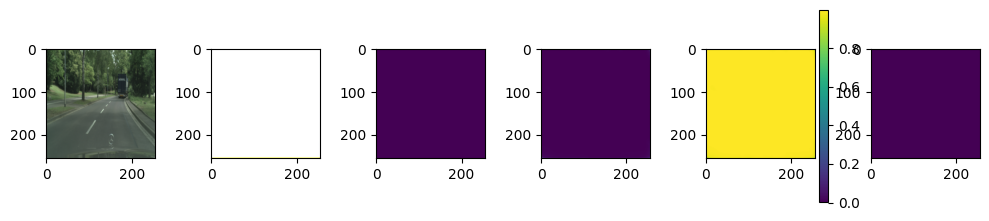

In [56]:
data,_ = next(iter(train_loader)) 

with torch.no_grad():
    x = data[-1].to(device)
    seg = seg_model(x)
    y= rec_model(x,seg)

components = seg.shape[1]

fig,ax = plt.subplots(1,2+components,figsize=(10,5))
scaled_x = scale_for_display(x)
sclaed_y = scale_for_display(y[-1])
ax[0].imshow(scaled_x[0].cpu().permute(1,2,0).numpy())
ax[1].imshow(sclaed_y[0].cpu().permute(1,2,0).numpy())



scaled_seg = torch.softmax(seg,dim=1)
vmin = scaled_seg[0].min().item()
vmax = scaled_seg[0].max().item()

for i in range(components):
    im = ax[2 + i].imshow(scaled_seg[0, i].cpu().numpy(), vmin=vmin, vmax=vmax)

fig.colorbar(im, ax=ax[2:].tolist(), shrink=0.5)
plt.tight_layout()

In [60]:
y

[tensor([[[[-1.0000, -1.0000, -1.0000, -1.0000],
           [-1.0000, -1.0000, -1.0000, -1.0000],
           [-1.0000, -1.0000, -1.0000, -1.0000],
           [-1.0000, -1.0000, -1.0000, -1.0000]],
 
          [[-1.0000, -1.0000, -1.0000, -1.0000],
           [-1.0000, -1.0000, -1.0000, -1.0000],
           [-1.0000, -1.0000, -1.0000, -1.0000],
           [-1.0000, -1.0000, -1.0000, -1.0000]],
 
          [[-1.0000, -1.0000, -1.0000, -1.0000],
           [-1.0000, -1.0000, -1.0000, -1.0000],
           [-1.0000, -1.0000, -1.0000, -1.0000],
           [-1.0000, -1.0000, -1.0000, -1.0000]]],
 
 
         [[[-0.9906, -1.0000, -1.0000, -1.0000],
           [-1.0000, -1.0000, -1.0000, -1.0000],
           [-1.0000, -1.0000, -1.0000, -1.0000],
           [-1.0000, -1.0000, -1.0000, -1.0000]],
 
          [[-0.9989, -1.0000, -1.0000, -1.0000],
           [-1.0000, -1.0000, -1.0000, -1.0000],
           [-1.0000, -1.0000, -1.0000, -1.0000],
           [-1.0000, -1.0000, -1.0000, -1.0000]],
 
  

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..-0.9999987].


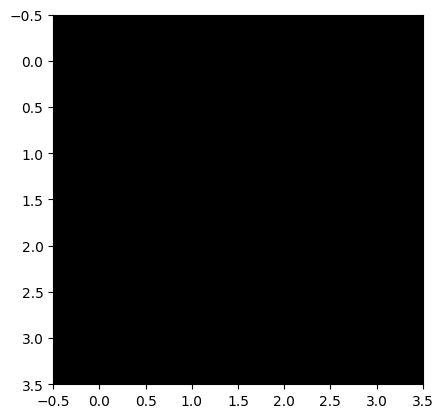

In [66]:
plt.imshow(y[-7][0].permute(1,2,0).detach().cpu().numpy())